# M7 · Ranking & CTR — A Complete pCTR Pipeline You Can Run

**Companion to curriculum lesson M7. Written for someone new to machine learning.**

We're going to build one full **pCTR** model from scratch. "pCTR" stands for
**predicted Click-Through Rate** — for each ad we show a person, the model predicts
*the probability they will click it* (a number between 0 and 1, like `0.04` = "about a
4% chance of a click"). Ranking ads by this probability (times the advertiser's bid) is
how ad systems decide what to show.

**The plan — a normal ML pipeline, one step at a time:**
1. **Make some example data** (fake ad impressions we fully understand).
2. **Look at the data** so we know what's in it.
3. **Split** into a *training* set and a *test* set (and understand why).
4. **Train** a pCTR model.
5. **Predict** click probabilities on data the model never saw.
6. **Check it ranks well** (ROC / AUC).
7. **Check the probabilities are honest** (calibration).
8. **Rank ads** and see clicked ads rise to the top.
9. **Combine pCTR with the bid** to pick the most *valuable* ad (not just the likeliest click).
10. **Prove it works** with four graphs.

Everything runs in Google Colab with **no installation**. Read the text above each code
cell, then run the cell (Shift+Enter). Let's go.

## Step 1 · Make some simple example data

A machine-learning model learns from **examples**. Each example here is **one ad shown to
one person** (called an *impression*). For each impression we record a few **features**
(things we know *before* showing the ad) and a **label** (what happened afterwards — did
they click, `1`, or not, `0`).

Our features:
- `relevance` — how well the ad matches the person's interests (0 = unrelated, 1 = perfect).
- `position` — which slot the ad appeared in (1 = top of page, 10 = bottom). Higher slots
  get seen less, so they're clicked less.
- `ad_quality` — a general quality score of the ad itself (0 to 1).
- `is_mobile` — 1 if on a phone, 0 if on desktop.

**The trick that lets us prove correctness later:** *we* invent the real rule that
decides clicks. We compute a **true click probability** for each impression from the
features, then flip a weighted coin with that probability to get the click. Because we
know the true probability, at the end we can check whether the model recovered it.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"axes.grid": True, "grid.alpha": .3, "figure.autolayout": True})
BLUE, GREEN, RED, PURPLE, GOLD, GRAY = "#4C72B0", "#55A868", "#C44E52", "#8172B3", "#CCB974", "#888"

rng = np.random.default_rng(0)
N = 6000                                              # 6000 ad impressions

relevance  = rng.uniform(0, 1, N)
position   = rng.integers(1, 11, N)                  # slots 1..10
ad_quality = rng.uniform(0, 1, N)
is_mobile  = rng.integers(0, 2, N)

# The TRUE rule behind clicks (a "logit" = a score we turn into a probability).
# Higher relevance & quality -> more clicks; lower position number (higher on page) -> more clicks.
true_logit = (-3.0
              + 3.0 * relevance
              + 1.5 * ad_quality
              - 0.25 * position
              + 0.4 * is_mobile)
true_pctr = 1 / (1 + np.exp(-true_logit))            # squash the score into a 0..1 probability
clicked   = (rng.random(N) < true_pctr).astype(int)  # flip a coin with that probability

data = pd.DataFrame(dict(relevance=relevance, position=position, ad_quality=ad_quality,
                         is_mobile=is_mobile, true_pctr=true_pctr, clicked=clicked))
print("rows:", len(data), " | overall click rate:", round(data.clicked.mean(), 3))
data.head()

rows: 6000  | overall click rate: 0.174


## Step 2 · Look at the data before modelling

Always *look* at your data first. If clicks really depend on the features, we should be
able to see it: as `relevance` goes up, the click rate should go up; as `position` goes
down the page (bigger number), the click rate should drop. If these plots were flat,
there'd be nothing for the model to learn.

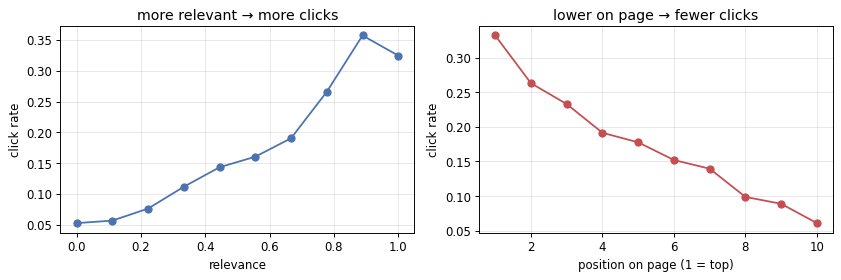

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
# click rate across relevance buckets
data["rel_bucket"] = pd.cut(data.relevance, 10, labels=False)
rel_ctr = data.groupby("rel_bucket").clicked.mean()
ax[0].plot(rel_ctr.index/9, rel_ctr.values, "o-", color=BLUE)
ax[0].set_xlabel("relevance"); ax[0].set_ylabel("click rate"); ax[0].set_title("more relevant → more clicks")
# click rate by position
pos_ctr = data.groupby("position").clicked.mean()
ax[1].plot(pos_ctr.index, pos_ctr.values, "o-", color=RED)
ax[1].set_xlabel("position on page (1 = top)"); ax[1].set_ylabel("click rate"); ax[1].set_title("lower on page → fewer clicks")
plt.show()

## Step 3 · Split into training and test sets

We must never grade a model on the same examples it learned from — that's like giving a
student the exam answers while they study. So we split the data:
- **Training set (75%)** — the model learns the pattern from these.
- **Test set (25%)** — locked away; we only use it to check how the model does on
  impressions it has *never seen*. This tells us if it will work on *future* ads.

We separate the **features** `X` (what the model is allowed to look at) from the **label**
`y` (what it's trying to predict). Note `true_pctr` is **not** a feature — in real life
you never know it; we only kept it to grade ourselves later.

In [3]:
from sklearn.model_selection import train_test_split

features = ["relevance", "position", "ad_quality", "is_mobile"]
X = data[features]
y = data["clicked"]

X_train, X_test, y_train, y_test, pctr_train, pctr_test = train_test_split(
    X, y, data.true_pctr, test_size=0.25, random_state=42, stratify=y)
print("training impressions:", len(X_train), " | test impressions:", len(X_test))

training impressions: 4500  | test impressions: 1500


## Step 4 · Train the pCTR model

A pCTR model outputs a probability, so we use **logistic regression** — the standard
starting model for "predict a probability of yes/no." Intuitively it learns a **weight**
for each feature (how much that feature pushes the click probability up or down), then
squashes the weighted sum into a 0–1 probability with the same sigmoid we used in Step 1.

Training means: the model tries weights, sees how wrong its probabilities are on the
training clicks (using a penalty called **log loss** that punishes confident-but-wrong
predictions), and adjusts the weights to reduce that penalty. `.fit()` runs that whole
loop for us.

In [4]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)          # <-- this is "training": learn weights from the data

print("learned weights (how each feature affects click probability):")
for f, w in zip(features, model.coef_[0]):
    print(f"  {f:<11}: {w:+.2f}")
print(f"  intercept  : {model.intercept_[0]:+.2f}")
print("\nNotice relevance & ad_quality got POSITIVE weights (push clicks up)")
print("and position got a NEGATIVE weight (further down the page = fewer clicks) —")
print("the model recovered the real rule from Step 1 just by looking at examples.")

learned weights (how each feature affects click probability):
  relevance  : +2.93
  position   : -0.23
  ad_quality : +1.80
  is_mobile  : +0.34
  intercept  : -3.25

Notice relevance & ad_quality got POSITIVE weights (push clicks up)
and position got a NEGATIVE weight (further down the page = fewer clicks) —
the model recovered the real rule from Step 1 just by looking at examples.


## Step 5 · Make predictions

Now we ask the trained model for the **click probability** of each impression in the
**test** set (data it never saw during training). `predict_proba(...)[:, 1]` gives the
probability of the "click" class for every row.

In [5]:
pred_pctr = model.predict_proba(X_test)[:, 1]     # predicted click probability, 0..1
out = X_test.copy()
out["predicted_pctr"] = pred_pctr.round(3)
out["actually_clicked"] = y_test.values
print("a few predictions on unseen impressions:")
print(out.head(6).to_string(index=False))

a few predictions on unseen impressions:
 relevance  position  ad_quality  is_mobile  predicted_pctr  actually_clicked
  0.968401         1    0.888908          1           0.785                 1
  0.526212         7    0.704388          1           0.155                 1
  0.454595         2    0.383822          1           0.207                 0
  0.549080         5    0.693547          0           0.177                 0
  0.522677         8    0.480183          1           0.088                 0
  0.130573         2    0.374903          0           0.066                 0


## Step 6 · Does it *rank* well? (ROC and AUC)

The first job of a pCTR model is **ordering**: clicked ads should get higher scores than
non-clicked ones. **AUC** (Area Under the ROC Curve) measures exactly this. Read it as:

> *pick one impression that was clicked and one that wasn't at random — AUC is the
> probability the model gave the clicked one a higher score.*

- AUC = 0.5 → no better than a coin flip (useless).
- AUC = 1.0 → perfect ordering.
- Real ad models usually live around 0.7–0.8.

AUC on unseen test data: 0.779


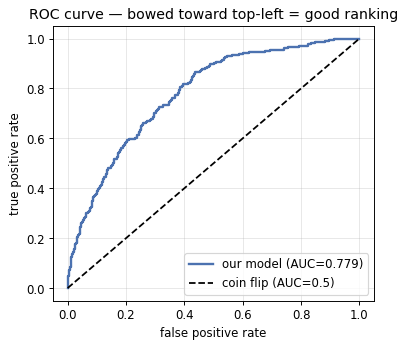

In [6]:
from sklearn.metrics import roc_auc_score, roc_curve

auc = roc_auc_score(y_test, pred_pctr)
fpr, tpr, _ = roc_curve(y_test, pred_pctr)
print("AUC on unseen test data:", round(auc, 3))

plt.figure(figsize=(4.6, 4.2))
plt.plot(fpr, tpr, color=BLUE, lw=2, label=f"our model (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="coin flip (AUC=0.5)")
plt.xlabel("false positive rate"); plt.ylabel("true positive rate")
plt.title("ROC curve — bowed toward top-left = good ranking"); plt.legend(); plt.show()

## Step 7 · Are the probabilities *honest*? (calibration)

Ranking isn't enough. Because ad systems multiply pCTR by the bid to decide what to show,
the number itself must be **truthful**: among impressions the model scored around 0.20,
about 20% should actually be clicked. That property is called **calibration**.

We check it with a **reliability diagram**: bucket impressions by predicted probability,
and for each bucket plot *predicted probability* (x) vs *actual click rate* (y). If the
model is honest, the points sit on the diagonal `y = x`.

On-diagonal means: when the model says 20%, real clicks ARE about 20%.


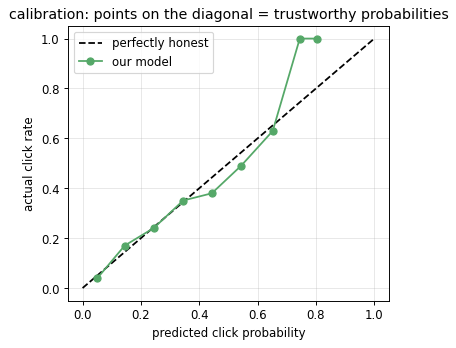

In [7]:
from sklearn.calibration import calibration_curve

frac_pos, mean_pred = calibration_curve(y_test, pred_pctr, n_bins=10)
plt.figure(figsize=(4.6, 4.2))
plt.plot([0, 1], [0, 1], "k--", label="perfectly honest")
plt.plot(mean_pred, frac_pos, "o-", color=GREEN, label="our model")
plt.xlabel("predicted click probability"); plt.ylabel("actual click rate")
plt.title("calibration: points on the diagonal = trustworthy probabilities")
plt.legend(); plt.show()
print("On-diagonal means: when the model says 20%, real clicks ARE about 20%.")

## Step 8 · Rank the ads (and watch clicked ads rise)

This is the product output. Imagine a page where several candidate ads compete for the
top slot. We score them all with pCTR and sort highest-first. A good model puts the ads
people actually clicked near the top.

We measure this two ways a beginner can trust:
- **Average rank of clicked ads** should be near the top (small number).
- A histogram of scores for **clicked vs non-clicked** impressions: the clicked ones
  should sit clearly to the right (higher scores).

clicked impressions land at average rank 405 out of 1500 (top 27% on average)


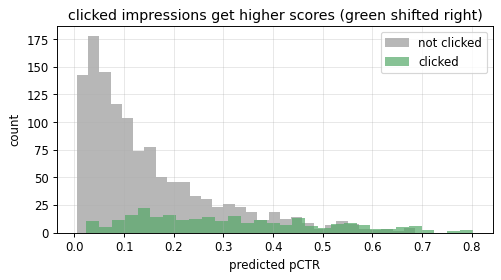

In [8]:
order = np.argsort(-pred_pctr)                 # sort impressions by predicted pCTR, highest first
ranks = np.empty_like(order); ranks[order] = np.arange(1, len(order) + 1)
clicked_ranks = ranks[y_test.values == 1]
print(f"clicked impressions land at average rank "
      f"{clicked_ranks.mean():.0f} out of {len(ranks)} "
      f"(top {100*clicked_ranks.mean()/len(ranks):.0f}% on average)")

plt.figure(figsize=(6, 3.4))
plt.hist(pred_pctr[y_test.values == 0], bins=30, alpha=.6, color=GRAY, label="not clicked")
plt.hist(pred_pctr[y_test.values == 1], bins=30, alpha=.7, color=GREEN, label="clicked")
plt.xlabel("predicted pCTR"); plt.ylabel("count")
plt.title("clicked impressions get higher scores (green shifted right)"); plt.legend(); plt.show()

## Step 9 · pCTR × bid — ranking by *value*, not just clicks

An ad system doesn't only want clicks; it wants **value**. If advertiser A bids \$8 and
advertiser B bids \$3, the fair way to compare them is **expected value = pCTR × bid**
(how much money we expect per impression). A slightly less likely click on a high bid can
beat a likely click on a tiny bid. This is the bridge from the ML score to the auction —
and it's *why calibration mattered* in Step 7 (a wrong probability makes this arithmetic
wrong).

ad  bid  pctr  expected_value
 A  8.0  0.01            0.08
 B  3.0  0.04            0.12
 C  5.0  0.02            0.10

Winner by expected value: Ad B (value 0.120) — not the highest bid, not blindly the highest pCTR.


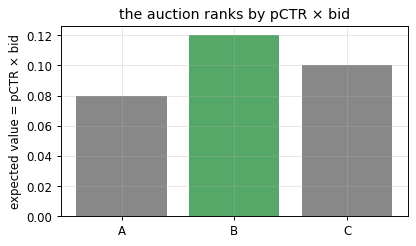

In [9]:
candidates = pd.DataFrame({
    "ad":  ["A", "B", "C"],
    "bid": [8.0, 3.0, 5.0],
    "pctr":[0.010, 0.040, 0.020],   # from the pCTR model
})
candidates["expected_value"] = candidates.pctr * candidates.bid
winner = candidates.sort_values("expected_value", ascending=False).iloc[0]
print(candidates.to_string(index=False))
print(f"\nWinner by expected value: Ad {winner.ad} "
      f"(value {winner.expected_value:.3f}) — not the highest bid, not blindly the highest pCTR.")

plt.figure(figsize=(5, 3))
plt.bar(candidates.ad, candidates.expected_value, color=[GRAY, GREEN, GRAY])
plt.ylabel("expected value = pCTR × bid"); plt.title("the auction ranks by pCTR × bid"); plt.show()

## Step 10 · The proof — four graphs that show it's working

Time to convince ourselves the model is genuinely correct, not just plausible. Because we
*invented* the true click probability in Step 1, we have a luxury real engineers don't: we
can compare the model's prediction to the **actual truth**.

1. **Predicted vs TRUE pCTR** — each dot is one impression. On the diagonal = the model
   recovered the real click probability it was never told.
2. **Calibration** — predicted vs *observed* click rate, on the diagonal = honest.
3. **Score distributions** — clicked (green) clearly right of not-clicked (grey).
4. **Predicted vs actual click rate by decile** — sort impressions into 10 groups by
   predicted pCTR; the bars (predicted) and dots (actual) should match, low to high.

AUC=0.779  |  predicted-vs-true correlation=0.996
All four graphs agree: the model's predictions track reality. The pipeline works.


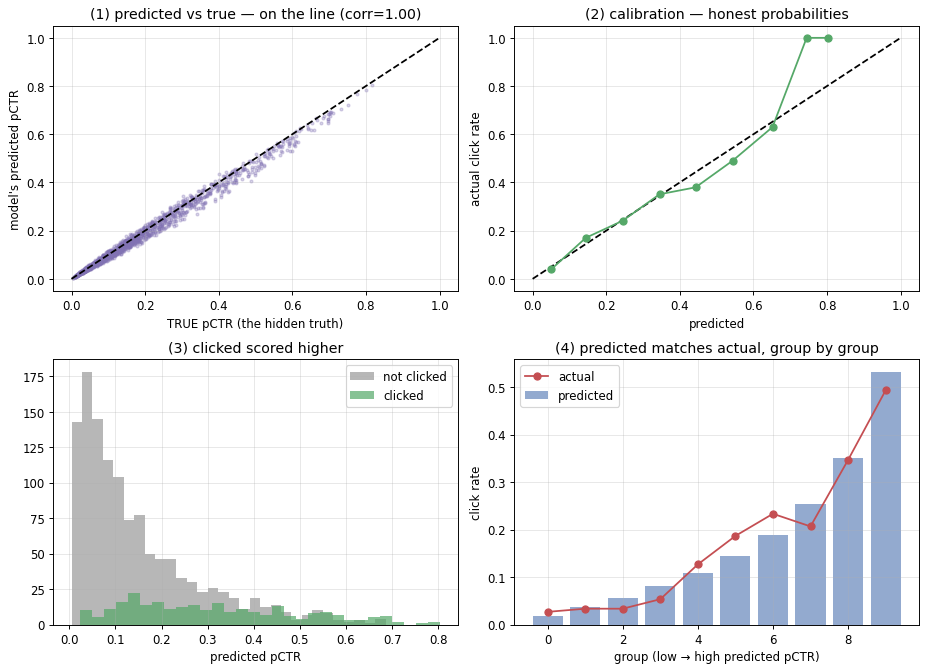

In [10]:
fig, ax = plt.subplots(2, 2, figsize=(11, 8))

# (1) predicted vs TRUE pctr
ax[0,0].scatter(pctr_test, pred_pctr, s=6, alpha=.3, color=PURPLE)
ax[0,0].plot([0,1],[0,1], "k--")
ax[0,0].set_xlabel("TRUE pCTR (the hidden truth)"); ax[0,0].set_ylabel("model's predicted pCTR")
corr = np.corrcoef(pctr_test, pred_pctr)[0,1]
ax[0,0].set_title(f"(1) predicted vs true — on the line (corr={corr:.2f})")

# (2) calibration
frac_pos, mean_pred = calibration_curve(y_test, pred_pctr, n_bins=10)
ax[0,1].plot([0,1],[0,1], "k--"); ax[0,1].plot(mean_pred, frac_pos, "o-", color=GREEN)
ax[0,1].set_xlabel("predicted"); ax[0,1].set_ylabel("actual click rate")
ax[0,1].set_title("(2) calibration — honest probabilities")

# (3) score distributions
ax[1,0].hist(pred_pctr[y_test.values==0], bins=30, alpha=.6, color=GRAY, label="not clicked")
ax[1,0].hist(pred_pctr[y_test.values==1], bins=30, alpha=.7, color=GREEN, label="clicked")
ax[1,0].set_xlabel("predicted pCTR"); ax[1,0].legend(); ax[1,0].set_title("(3) clicked scored higher")

# (4) predicted vs actual by decile
dec = pd.qcut(pred_pctr, 10, labels=False, duplicates="drop")
df = pd.DataFrame({"dec": dec, "pred": pred_pctr, "act": y_test.values})
g = df.groupby("dec").mean()
ax[1,1].bar(g.index, g.pred, color=BLUE, alpha=.6, label="predicted")
ax[1,1].plot(g.index, g.act, "o-", color=RED, label="actual")
ax[1,1].set_xlabel("group (low → high predicted pCTR)"); ax[1,1].set_ylabel("click rate")
ax[1,1].set_title("(4) predicted matches actual, group by group"); ax[1,1].legend()

plt.tight_layout(); plt.show()
print(f"AUC={roc_auc_score(y_test, pred_pctr):.3f}  |  predicted-vs-true correlation={corr:.3f}")
print("All four graphs agree: the model's predictions track reality. The pipeline works.")

---
## What you just built

A complete **pCTR ranking pipeline**, the core of every ads/recommendation system:

1. **Data → features + label** — each impression became a row the model can learn from.
2. **Train/test split** — so we measure real generalization, not memorization.
3. **Train a logistic-regression pCTR model** — it learned a weight per feature.
4. **Predict probabilities** on unseen data.
5. **AUC** checked *ranking*; **calibration** checked the probabilities are *honest*.
6. **Ranking** put clicked ads on top; **pCTR × bid** ranked by *value* for the auction.
7. **Four proof graphs** showed the predictions match the hidden truth.

**Where this connects to lesson M7:** this was a **pointwise** pCTR model (M7.1). M7.2
adds **pairwise/listwise** ranking (learning "ad A should beat ad B" instead of an
absolute label), and M7.3 adds **multi-objective** heads (combine click + dwell + value)
and production CTR architectures (Wide&Deep, DeepFM, DCN, DLRM). The calibration you saw
in Step 7 is exactly what module **M8** teaches you to measure and repair.